<a href="https://colab.research.google.com/github/lilya2104/niias_lstm/blob/main/%D0%BB%D0%B5%D1%82%D0%BD%D1%8F%D1%8F_%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_1%D0%BC%D0%B8%D0%BD_%D1%81_%D0%B2%D1%8B%D0%B1%D1%80%D0%BE%D1%81%D0%B0%D0%BC%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_readcsv = pd.read_csv('/content/drive/My Drive/MetroPT3(AirCompressor).csv')

In [ ]:
df_readcsv.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [ ]:
df_readcsv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  object 
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1

In [ ]:
# превратим дату в индекс
df_readcsv.set_index('timestamp', inplace=True)
# превратим дату (индекс) в объект datetime
df_readcsv.index = pd.to_datetime(df_readcsv.index)

In [ ]:
columns = ['TP3', 'DV_pressure', 'Oil_temperature', 'Motor_current', 'TP2']
df = df_readcsv[columns]

In [ ]:
df.head()

,TP3,DV_pressure,Oil_temperature,Motor_current,TP2
timestamp,,,,,
2020-02-01 00:00:00,9.358,-0.024,53.600,0.0400,-0.012
2020-02-01 00:00:10,9.348,-0.022,53.675,0.0400,-0.014
2020-02-01 00:00:19,9.338,-0.022,53.600,0.0425,-0.012
2020-02-01 00:00:29,9.328,-0.022,53.425,0.0400,-0.012
2020-02-01 00:00:39,9.318,-0.022,53.475,0.0400,-0.012


In [ ]:
df.info()
print(f'Количество записей {len(df)}')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1516948 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   TP3              1516948 non-null  float64
 1   DV_pressure      1516948 non-null  float64
 2   Oil_temperature  1516948 non-null  float64
 3   Motor_current    1516948 non-null  float64
 4   TP2              1516948 non-null  float64
dtypes: float64(5)
memory usage: 69.4 MB
Количество записей 1516948


In [ ]:
from ipywidgets import HBox, VBox, Output, HTML
from IPython.display import display

# Создаём виджеты
out1 = Output()
out2 = Output()

# Заполняем виджеты
with out1:
  display(df.head())
with out2:
  display(df.info())

# Размещаем в строку
display(HBox([out1, out2]))

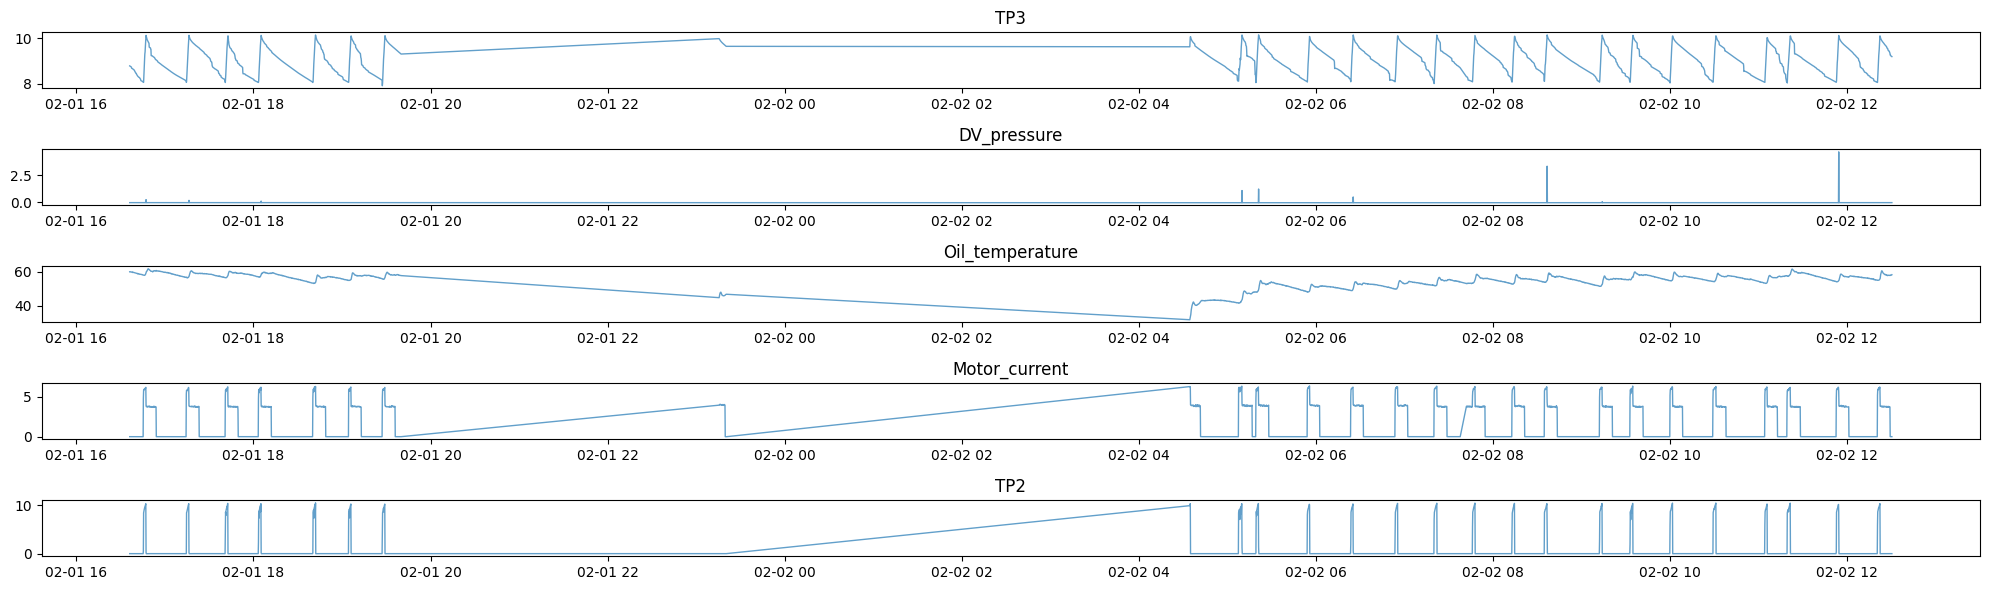

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(20, 6))

df_ = df[6000:10000]

for idx, col in enumerate(columns):
  axes[idx].plot(df_.index, df_[col], linewidth=1, alpha=0.7)
  axes[idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

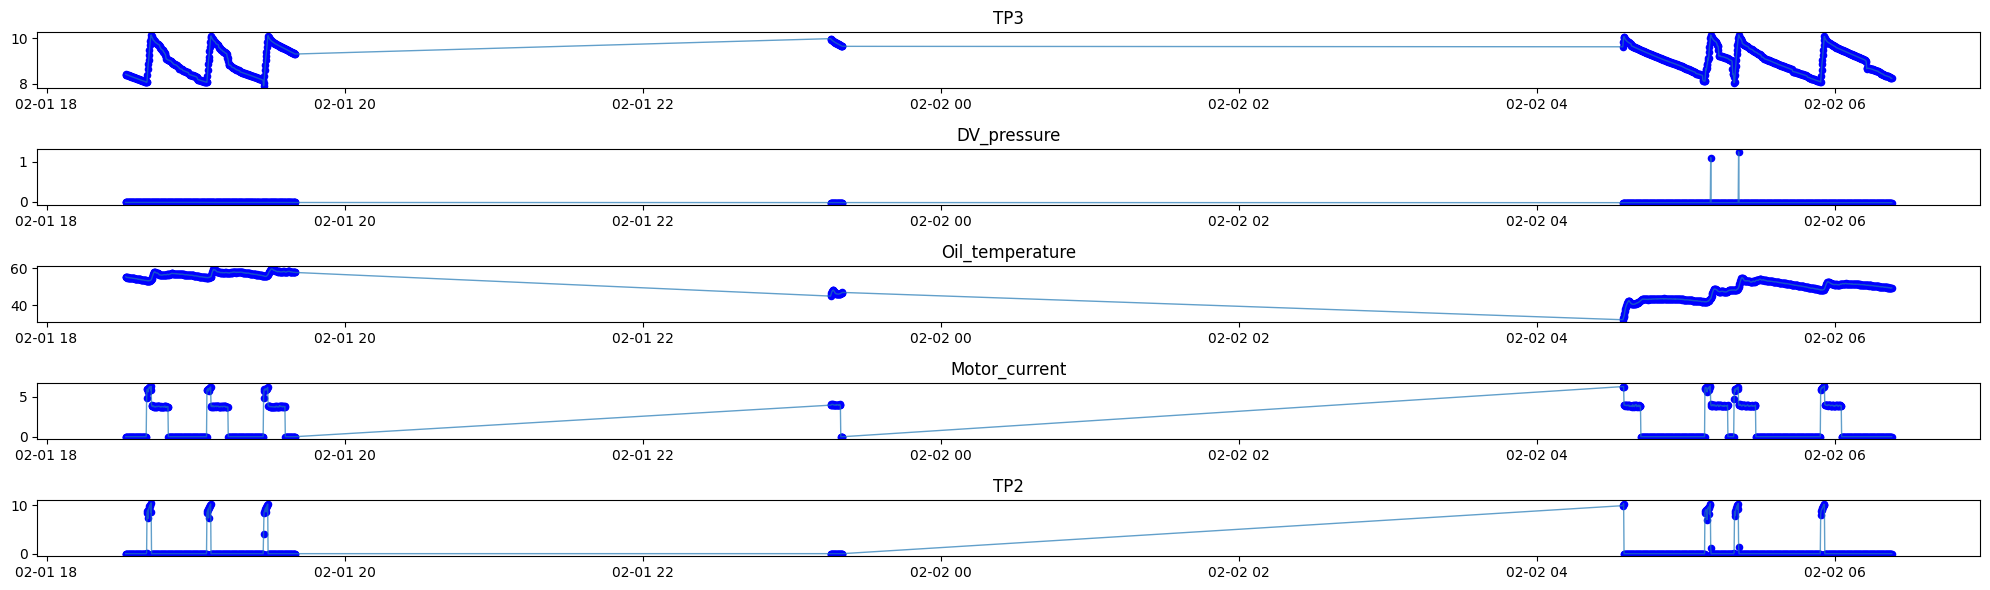

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(20, 6))

df_ = df[6700:7800]

for idx, col in enumerate(columns):
  axes[idx].plot(df_.index, df_[col], linewidth=1, alpha=0.7)
  axes[idx].scatter(df_.index, df_[col], color='blue', s=20)
  axes[idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# проверяем на пропуски
for col in columns:
  nan_count = df[col].isna().sum()
  print(f"{col}: {nan_count} NaN")

TP3: 0 NaN
DV_pressure: 0 NaN
Oil_temperature: 0 NaN
Motor_current: 0 NaN
TP2: 0 NaN


In [ ]:
# изменим шаг данных на минутный
df_min = df.resample(rule = 'T').mean()
df_min.head()

/tmp/ipykernel_1265/3429585614.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_min = df.resample(rule = 'T').mean()


,TP3,DV_pressure,Oil_temperature,Motor_current,TP2
timestamp,,,,,
2020-02-01 00:00:00,9.327429,-0.022857,53.521429,0.040357,-0.012286
2020-02-01 00:01:00,9.260000,-0.023333,53.420833,0.040000,-0.013000
2020-02-01 00:02:00,9.198333,-0.022333,53.325000,0.040000,-0.012667
2020-02-01 00:03:00,9.136667,-0.022667,53.200000,0.040000,-0.012333
2020-02-01 00:04:00,9.075667,-0.023000,53.129167,0.040000,-0.013000


In [ ]:
df_min.info()
print(f'Количество записей {len(df_min)}')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 306960 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:00
Freq: min
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TP3              252720 non-null  float64
 1   DV_pressure      252720 non-null  float64
 2   Oil_temperature  252720 non-null  float64
 3   Motor_current    252720 non-null  float64
 4   TP2              252720 non-null  float64
dtypes: float64(5)
memory usage: 14.1 MB
Количество записей 306960


In [ ]:
# проверяем где именно появились NaN, на примере TP3 (так как во всех столбцах одинаковое количество NaN)
nan_mask = df_min['TP3'].isna()
print(f"Всего NaN: {nan_mask.sum()}")
print(f"Процент NaN: {nan_mask.sum() / len(df_min) * 100:.2f}%")

print(df_min[nan_mask].head(10))

Всего NaN: 54240
Процент NaN: 17.67%
                     TP3  DV_pressure  Oil_temperature  Motor_current  TP2
timestamp                                                                 
2020-02-01 12:49:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 12:50:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 12:51:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 12:52:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:41:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:42:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:43:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:44:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:45:00  NaN          NaN              NaN            NaN  NaN
2020-02-01 19:46:00  NaN          NaN              NaN            NaN  NaN


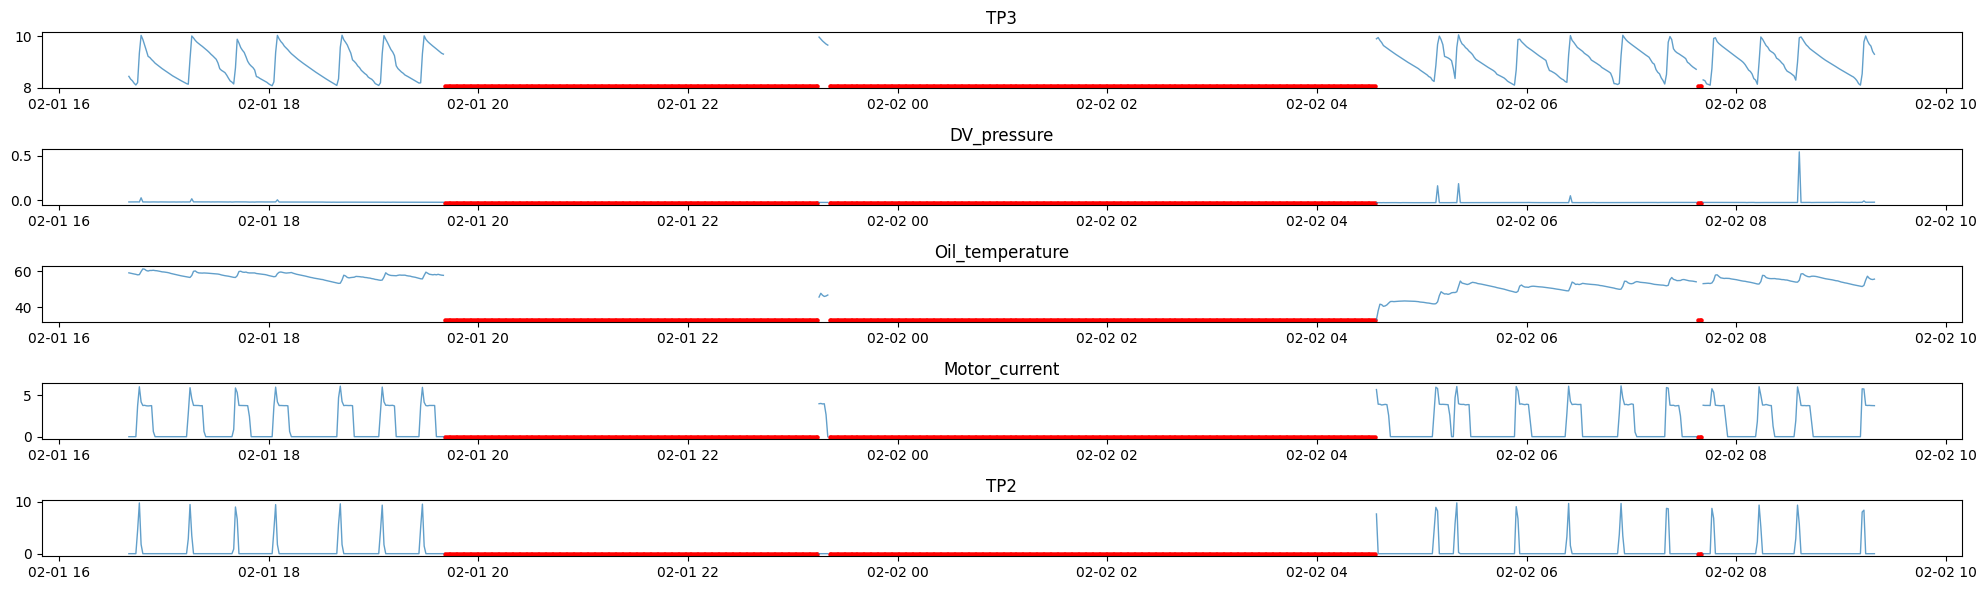

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(20, 6))
df_min_ = df_min[1000:2000]

for idx, col in enumerate(columns):
  # красным отмечаем nan-значения
  nan_mask = df_min_[col].isna()
  if nan_mask.any():
    nan_indices = df_min_.index[nan_mask]
    axes[idx].scatter(nan_indices, [df_min_[col].min()] * len(nan_indices), color='red', s=5)

  axes[idx].plot(df_min_.index, df_min_[col], linewidth=1, alpha=0.7)
  axes[idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# удаляем nan-значения в таблице, так как они создаются сами
df_nonan = df_min.dropna()

In [ ]:
# проверяем наличие NaN после удаления
nan_mask = df_nonan['TP3'].isna()
print(f"Всего NaN: {nan_mask.sum()}")
print(f"Процент NaN: {nan_mask.sum() / len(df_nonan) * 100:.2f}%")

df_nonan.info()
print(f'Количество записей {len(df_nonan)}')

Всего NaN: 0
Процент NaN: 0.00%
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252720 entries, 2020-02-01 00:00:00 to 2020-09-01 03:59:00
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TP3              252720 non-null  float64
 1   DV_pressure      252720 non-null  float64
 2   Oil_temperature  252720 non-null  float64
 3   Motor_current    252720 non-null  float64
 4   TP2              252720 non-null  float64
dtypes: float64(5)
memory usage: 11.6 MB
Количество записей 252720


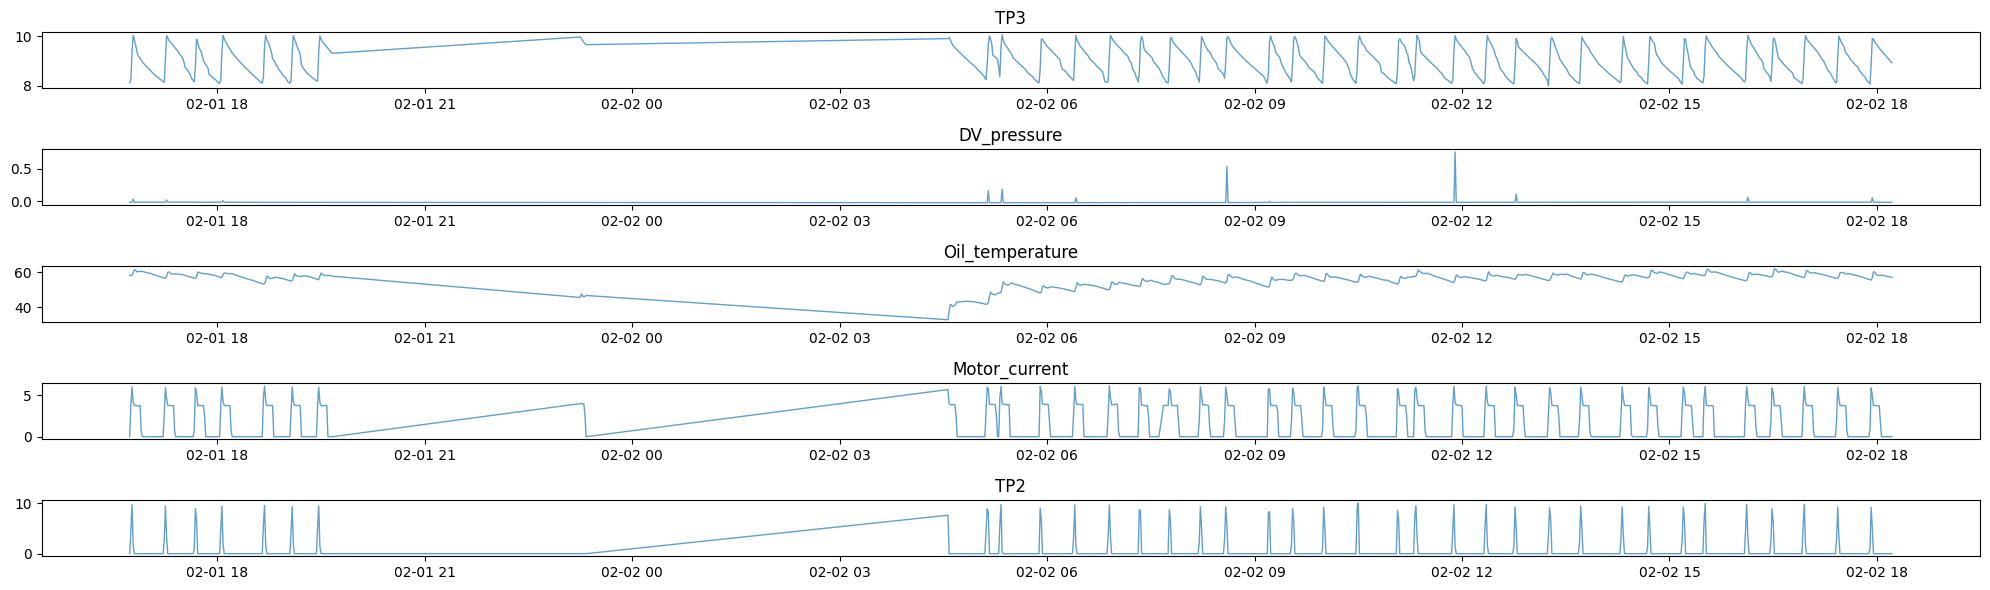

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(20, 6))
df_nonan_ = df_nonan[1000:2000]

for idx, col in enumerate(columns):
  nan_mask = df_nonan_[col].isna()
  if nan_mask.any():
    nan_indices = df_nonan_.index[nan_mask]
    axes[idx].scatter(nan_indices, [df_nonan_[col].min()] * len(nan_indices), color='red', s=5, alpha=0.5)

  axes[idx].plot(df_nonan_.index, df_nonan_[col], linewidth=1, alpha=0.7)
  axes[idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

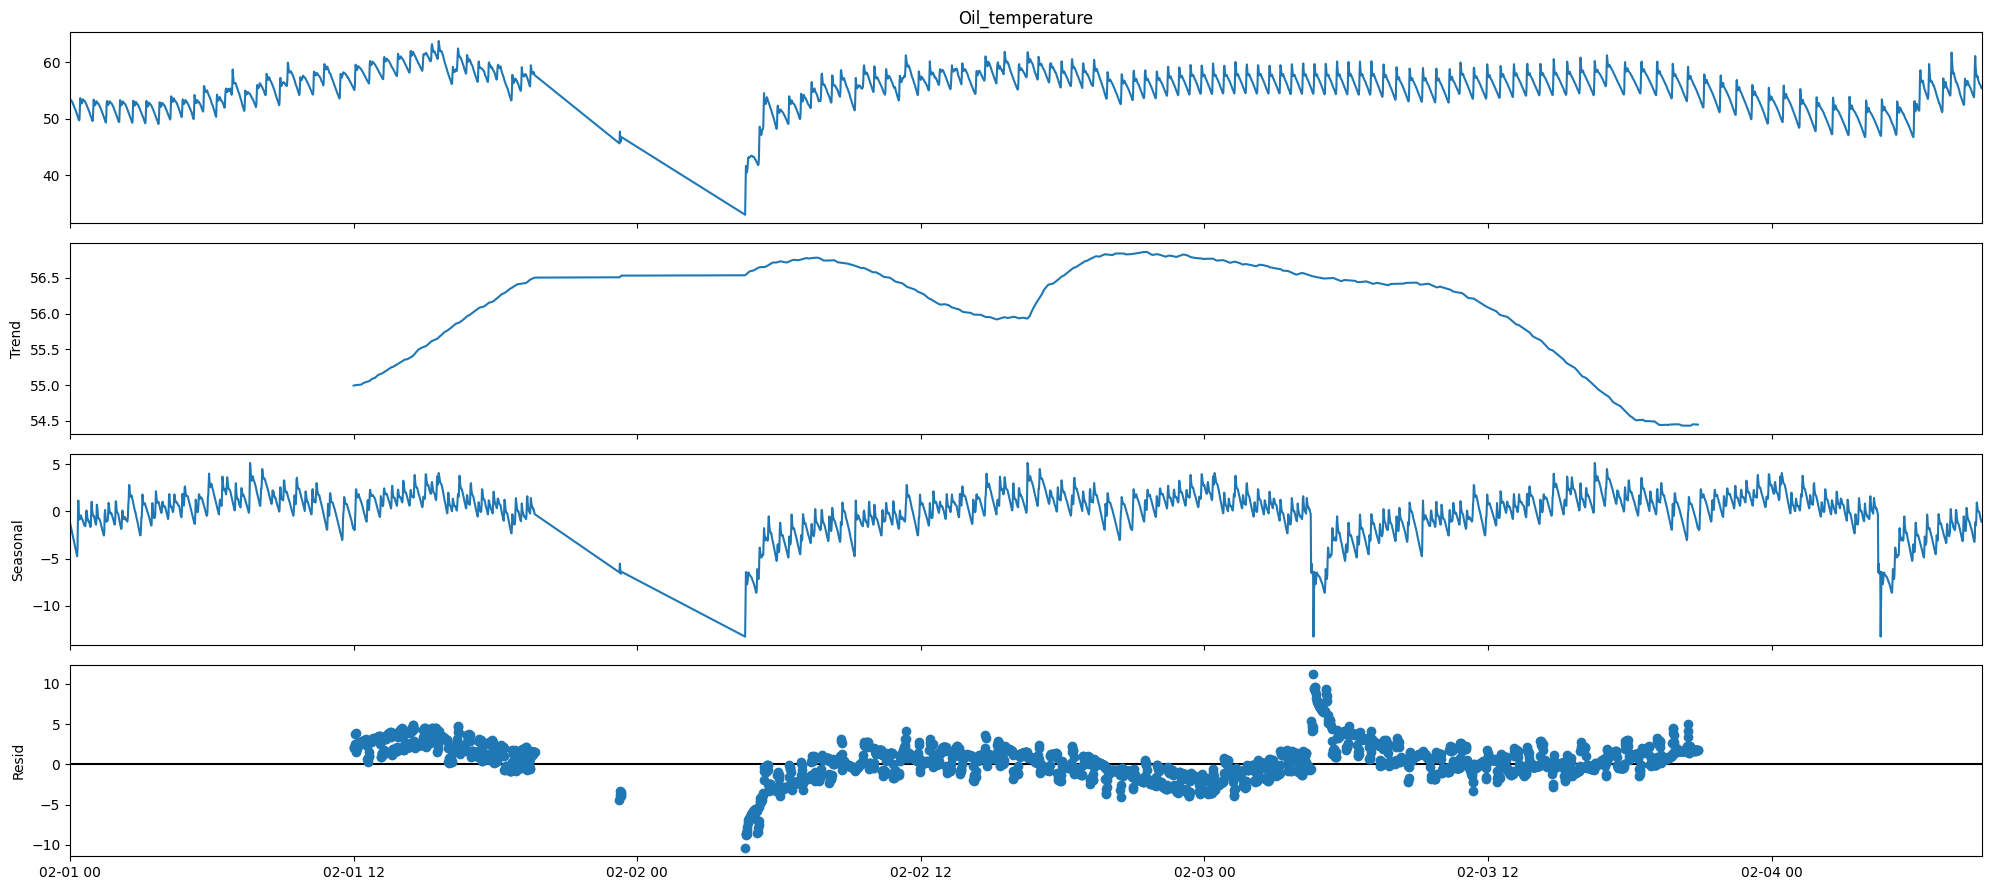

In [ ]:
days = 3
period = int(60/1*24) # так как одна точка - 1 минута, в часе - 60/1=60, в сутках - 24*60=1440
points_for_plot = days * period
df_plot = df_nonan.iloc[:points_for_plot]

rcParams['figure.figsize'] = 20, 9

decompose = seasonal_decompose(df_plot['Oil_temperature'], period=period)
decompose.plot()
plt.show()

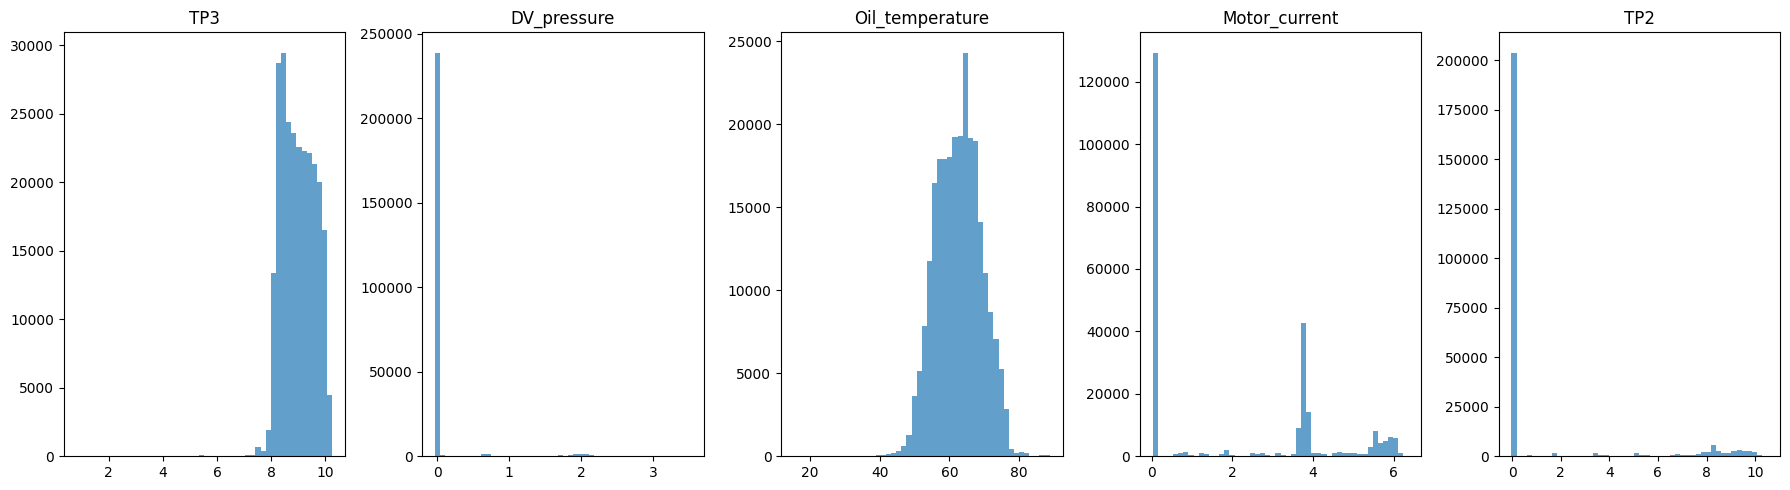

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, col in enumerate(columns):
    axes[idx].hist(df_nonan[col], bins=50, alpha=0.7)
    axes[idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

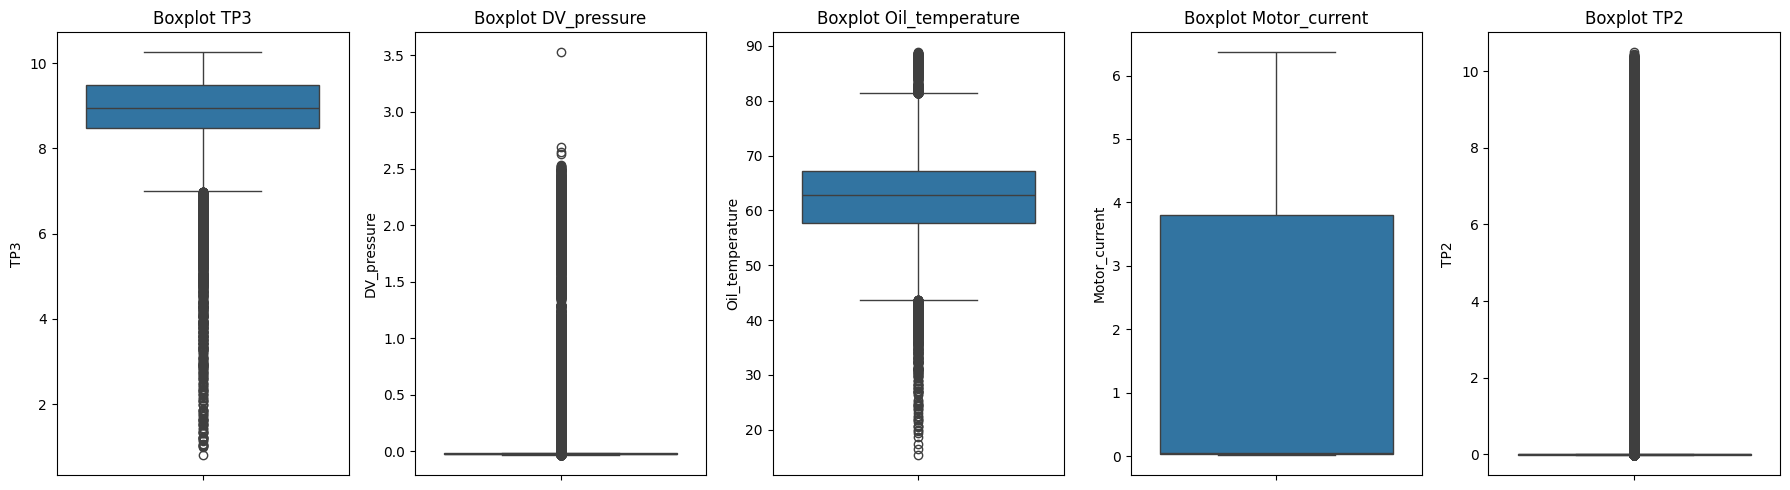

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, col in enumerate(columns):

    sns.boxplot(data=df_nonan, y=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot {col}', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
for col in columns:
  print(f"{col}: нижняя={df_nonan[col].min():.4f}, верхняя={df_nonan[col].max():.4f}, среднее={df_nonan[col].mean()}")

TP3: нижняя=0.8080, верхняя=10.2520, среднее=8.980921492202926
DV_pressure: нижняя=-0.0313, верхняя=3.5260, среднее=0.055389583465232074
Oil_temperature: нижняя=15.4000, верхняя=88.7958, среднее=62.64295462958252
Motor_current: нижняя=0.0200, верхняя=6.3633, среднее=2.056200328827123
TP2: нижняя=-0.0257, верхняя=10.4970, среднее=1.3808829032130425


In [ ]:
# регуляризация данных
scaler = MinMaxScaler(feature_range=(0, 1))

df_scaled = df_nonan.copy()
scaled_values = scaler.fit_transform(df_scaled)

df_scaled = pd.DataFrame(
    scaled_values,
    columns=df_nonan.columns,
    index=df_nonan.index
)

In [ ]:
df_scaled.head()

,TP3,DV_pressure,Oil_temperature,Motor_current,TP2
timestamp,,,,,
2020-02-01 00:00:00,0.902100,0.002383,0.519395,0.003209,0.001272
2020-02-01 00:01:00,0.894960,0.002249,0.518024,0.003153,0.001204
2020-02-01 00:02:00,0.888430,0.002530,0.516719,0.003153,0.001235
2020-02-01 00:03:00,0.881900,0.002436,0.515016,0.003153,0.001267
2020-02-01 00:04:00,0.875441,0.002343,0.514051,0.003153,0.001204


In [ ]:
df_x_tp2 = df_scaled[columns[:-1]]
df_x_tp2.head()

,TP3,DV_pressure,Oil_temperature,Motor_current
timestamp,,,,
2020-02-01 00:00:00,0.902100,0.002383,0.519395,0.003209
2020-02-01 00:01:00,0.894960,0.002249,0.518024,0.003153
2020-02-01 00:02:00,0.888430,0.002530,0.516719,0.003153
2020-02-01 00:03:00,0.881900,0.002436,0.515016,0.003153
2020-02-01 00:04:00,0.875441,0.002343,0.514051,0.003153


In [ ]:
df_y_tp2 = df_scaled['TP2']
df_y_tp2.head()

,TP2
timestamp,
2020-02-01 00:00:00,0.001272
2020-02-01 00:01:00,0.001204
2020-02-01 00:02:00,0.001235
2020-02-01 00:03:00,0.001267
2020-02-01 00:04:00,0.001204


In [ ]:
# создание скользящего окна
x_tp2, y_tp2 = [], []
window = 15

for i in range(window, len(df_scaled)):
  x_tp2.append(df_x_tp2.iloc[i - window:i].values)
  y_tp2.append(df_y_tp2.iloc[i])

x_tp2 = np.array(x_tp2)
y_tp2 = np.array(y_tp2)

In [ ]:
print("df_scaled len:", len(df_scaled))
print(f"x_tp2.shape: {x_tp2.shape}")  # количество окон, длина окна, количество признаков
print(f"y_tp2.shape: {y_tp2.shape}")

print("\nПервое окно:")
print(x_tp2[0, :, :])

print("\nЦель для первого окна:") # значение для N+1
print(y_tp2[0])

df_scaled len: 252720
x_tp2.shape: (252705, 15, 4)
y_tp2.shape: (252705,)

Первое окно:
[[0.90209959 0.00238274 0.519395   0.00320922]
 [0.89495976 0.00224888 0.51802441 0.00315292]
 [0.88843004 0.00252999 0.51671871 0.00315292]
 [0.88190032 0.00243628 0.51501561 0.00315292]
 [0.8754412  0.00234258 0.51405053 0.00315292]
 [0.86901737 0.00243628 0.51342606 0.00315292]
 [0.8628406  0.00234258 0.51081465 0.00302154]
 [0.85666384 0.00243628 0.50871416 0.00315292]
 [0.85052238 0.00243628 0.50672722 0.0032186 ]
 [0.8444515  0.00243628 0.50422935 0.00315292]
 [0.83848652 0.00215517 0.50139086 0.00302154]
 [0.83255683 0.00215517 0.49957423 0.00315292]
 [0.82676832 0.00224888 0.49707636 0.00302154]
 [0.82097981 0.00243628 0.49440817 0.00308723]
 [0.81540308 0.00234258 0.49151292 0.00315292]]

Цель для первого окна:
0.001140395337050165


In [ ]:
split = int(len(y_tp2) * 0.7)

x_tp2_train = x_tp2[:split]
x_tp2_test = x_tp2[split:]
y_tp2_train = y_tp2[:split]
y_tp2_test = y_tp2[split:]

In [ ]:
print("df_scaled len:", len(df_scaled), "\n")
print(f"x_tp2_train len: {len(x_tp2_train)}, y_tp2_train len: {len(y_tp2_train)}")
print(f"x_tp2_test len: {len(x_tp2_test)}, y_tp2_test len: {len(y_tp2_test)}")

df_scaled len: 252720 

x_tp2_train len: 176893, y_tp2_train len: 176893
x_tp2_test len: 75812, y_tp2_test len: 75812


In [ ]:
# создание модели
model = Sequential([
    LSTM(64, input_shape=(x_tp2.shape[1], x_tp2.shape[2])),  # 64 нейрона
    Dense(1)  # 1 выход - предсказание TP2(y)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_tp2 = model.fit(
    x_tp2_train, y_tp2_train,
    validation_data=(x_tp2_test, y_tp2_test),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 0.0224 - mae: 0.0871 - val_loss: 0.0240 - val_mae: 0.0813
Epoch 2/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0159 - mae: 0.0683 - val_loss: 0.0195 - val_mae: 0.0834
Epoch 3/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 0.0136 - mae: 0.0616 - val_loss: 0.0166 - val_mae: 0.0731
Epoch 4/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 0.0118 - mae: 0.0551 - val_loss: 0.0154 - val_mae: 0.0629
Epoch 5/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 0.0110 - mae: 0.0514 - val_loss: 0.0135 - val_mae: 0.0644
Epoch 6/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 0.0103 - mae: 0.0490 - val_loss: 0.0126 - val_mae: 0.0552
Epoch 7/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 0.0099 - mae: 0.0471 - val_loss: 0.0128 - val_mae: 0.0686
Epoch 8/20
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 0.0094 - mae: 0.0452 - val_loss: 0.0123 - val_mae: 0.0620
Epoch 9/20
2764/2764 ━━━━━━

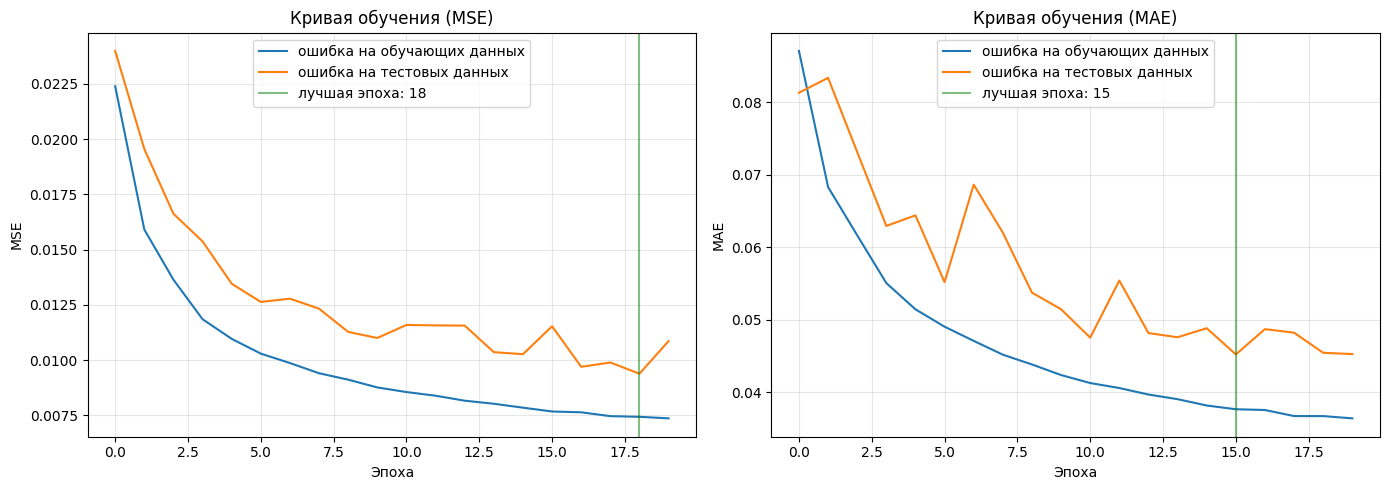

In [ ]:
best_epoch_mse = np.argmin(history_tp2.history['val_loss'])
best_epoch_mae = np.argmin(history_tp2.history['val_mae'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_tp2.history['loss'], label='ошибка на обучающих данных')
plt.plot(history_tp2.history['val_loss'], label='ошибка на тестовых данных')
plt.axvline(x=best_epoch_mse, color='green', label=f'лучшая эпоха: {best_epoch_mse}', alpha=0.5)
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Кривая обучения (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_tp2.history['mae'], label='ошибка на обучающих данных')
plt.plot(history_tp2.history['val_mae'], label='ошибка на тестовых данных')
plt.axvline(x=best_epoch_mae, color='green', label=f'лучшая эпоха: {best_epoch_mae}', alpha=0.5)
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Кривая обучения (MAE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
y_tp2_pred = model.predict(x_tp2_test)

2370/2370 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


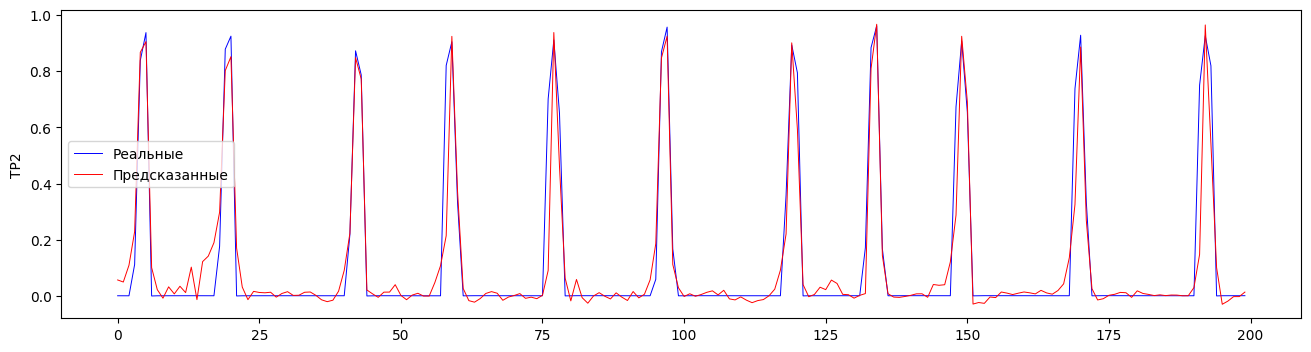

In [ ]:
plt.figure(figsize=(16, 4))
plt.plot(y_tp2_test[:200], label='Реальные', linewidth=0.7, color='blue')
plt.plot(y_tp2_pred[:200], label='Предсказанные', linewidth=0.7, color='red')
plt.ylabel('TP2')
plt.legend()
plt.show()

In [ ]:
# средняя квадратичная ошибка (на сколько в среднем модель ошибается, но штрафует за большие ошибки)
mse = mean_squared_error(y_tp2_test, y_tp2_pred)

# средняя абсолютная ошибка (на сколько в среднем модель ошибается)
mae = mean_absolute_error(y_tp2_test, y_tp2_pred)

# если мсе и мае примерно одинаковые, значит выбросов мало, если же мсе намного больше - есть сильные выбросы

# коэффициент детерминации (на сколько наша модель лучше другой (самой простой, которая предсказывает среднее значение))
r2 = r2_score(y_tp2_test, y_tp2_pred)

tp2_idx = df_min.columns.get_loc('TP2')
range_tp2 = scaler.data_max_[tp2_idx] - scaler.data_min_[tp2_idx]

mse_real = mse * (range_tp2 ** 2)
mae_real = mae * range_tp2

print(f"Минимум:                {df_min['TP2'].min():.4f}")
print(f"Максимум:               {df_min['TP2'].max():.4f}")
print(f"Среднее:                {df_min['TP2'].mean():.4f}")
print(f"Стандартное отклонение: {df_min['TP2'].std():.4f}")

print(f"\nМетрики   нормированный масштаб    реальный масштаб")
print(f"MSE              {mse:.4f}                 {mse_real:.4f}")
print(f"MAE              {mae:.4f}                 {mae_real:.4f}")
print(f"R^2              {r2:.4f}                 {r2:.4f}")

Минимум:                -0.0257
Максимум:               10.4970
Среднее:                1.3809
Стандартное отклонение: 3.0719

Метрики   нормированный масштаб    реальный масштаб
MSE              0.0094                 1.0387
MAE              0.0454                 0.4781
R^2              0.8775                 0.8775


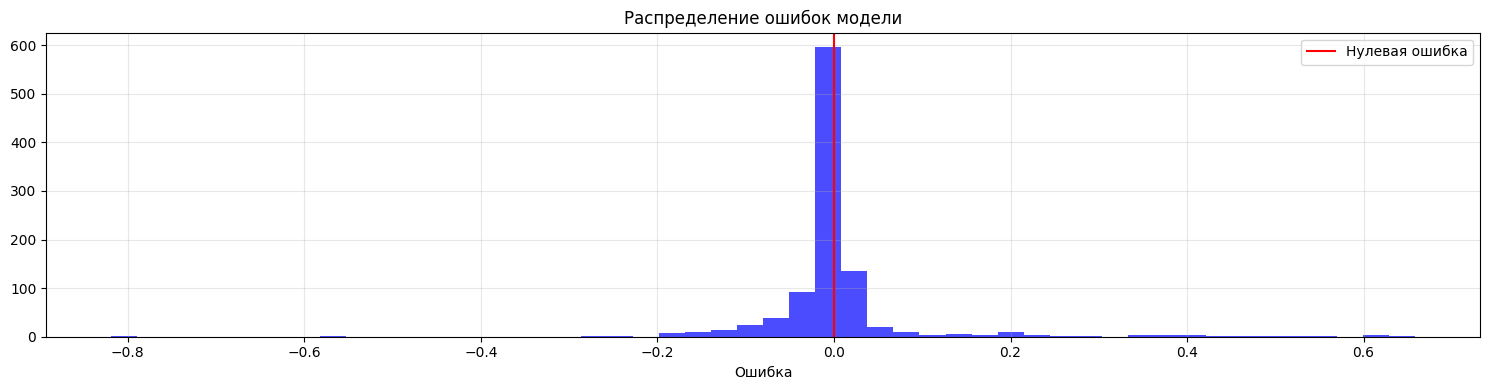

In [ ]:
y_pred_ = y_tp2_pred.flatten()
errors = y_tp2_test[:1000] - y_pred_[:1000]
std_error = np.std(errors)

plt.figure(figsize=(15, 4))
plt.hist(errors, bins=50, alpha=0.7, color='blue')
plt.axvline(x=0, color='red', linewidth=1.5, label='Нулевая ошибка')
plt.xlabel('Ошибка')
plt.title('Распределение ошибок модели', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

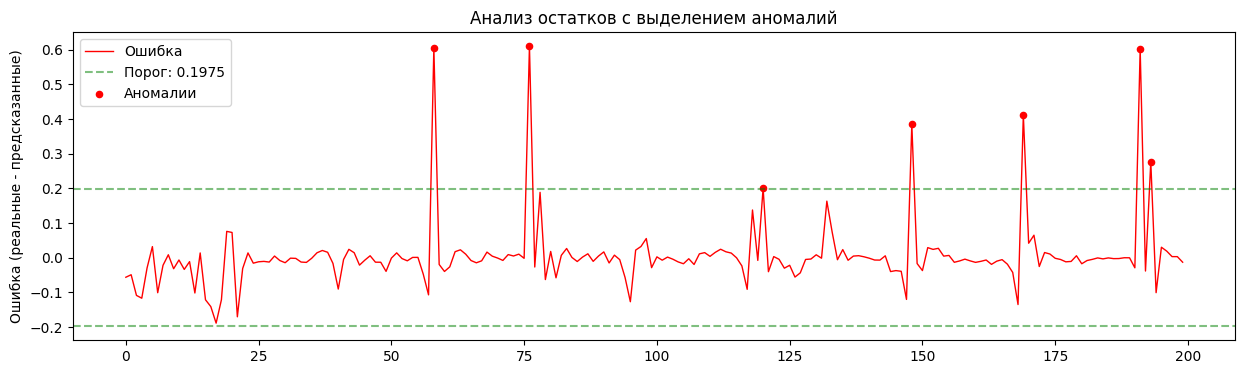

Найдено 7 аномальных точек
Процент аномалий: 3.50%


In [ ]:
y_pred_ = y_tp2_pred.flatten()
errors = y_tp2_test[:200] - y_pred_[:200]
std_error = np.std(errors)
threshold = 2 * std_error  # или 3 сигмы
anomaly_points = np.where(np.abs(errors) > threshold)[0]

plt.figure(figsize=(15, 4))
plt.plot(errors, linewidth=1, color='red', label='Ошибка')
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Порог: {threshold:.4f}', alpha=0.5)
plt.axhline(y=-threshold, color='green', linestyle='--', alpha=0.5)
plt.scatter(anomaly_points, errors[anomaly_points], color='red', s=20, label='Аномалии')
plt.ylabel('Ошибка (реальные - предсказанные)')
plt.legend()
plt.title('Анализ остатков с выделением аномалий')
plt.show()

# Вывод информации об аномалиях
print(f"Найдено {len(anomaly_points)} аномальных точек")
print(f"Процент аномалий: {len(anomaly_points)/len(errors)*100:.2f}%")

In [ ]:
df_scaled.head()

,TP3,DV_pressure,Oil_temperature,Motor_current,TP2
timestamp,,,,,
2020-02-01 00:00:00,0.902100,0.002383,0.519395,0.003209,0.001272
2020-02-01 00:01:00,0.894960,0.002249,0.518024,0.003153,0.001204
2020-02-01 00:02:00,0.888430,0.002530,0.516719,0.003153,0.001235
2020-02-01 00:03:00,0.881900,0.002436,0.515016,0.003153,0.001267
2020-02-01 00:04:00,0.875441,0.002343,0.514051,0.003153,0.001204


In [ ]:
df_x_oil = df_scaled[['TP2', 'TP3', 'DV_pressure', 'Motor_current']]
df_x_oil.head()

,TP2,TP3,DV_pressure,Motor_current
timestamp,,,,
2020-02-01 00:00:00,0.001272,0.902100,0.002383,0.003209
2020-02-01 00:01:00,0.001204,0.894960,0.002249,0.003153
2020-02-01 00:02:00,0.001235,0.888430,0.002530,0.003153
2020-02-01 00:03:00,0.001267,0.881900,0.002436,0.003153
2020-02-01 00:04:00,0.001204,0.875441,0.002343,0.003153


In [ ]:
df_y_oil = df_scaled['Oil_temperature']
df_y_oil.head()

,Oil_temperature
timestamp,
2020-02-01 00:00:00,0.519395
2020-02-01 00:01:00,0.518024
2020-02-01 00:02:00,0.516719
2020-02-01 00:03:00,0.515016
2020-02-01 00:04:00,0.514051


In [ ]:
# создание скользящего окна
x_oil, y_oil = [], []
window = 15

for i in range(window, len(df_scaled)):
  x_oil.append(df_x_oil.iloc[i - window:i].values)
  y_oil.append(df_y_oil.iloc[i])

x_oil = np.array(x_oil)
y_oil = np.array(y_oil)

In [ ]:
print("df_scaled len:", len(df_scaled))
print(f"x_oil.shape: {x_oil.shape}")  # количество окон, длина окна, количество признаков
print(f"y_oil.shape: {y_oil.shape}")

print("\nПервое окно:")
print(x_oil[0, :, :])

print("\nЦель для первого окна:") # значение для N+1
print(y_oil[0])

df_scaled len: 252720
x_oil.shape: (252705, 15, 4)
y_oil.shape: (252705,)

Первое окно:
[[0.00127163 0.90209959 0.00238274 0.00320922]
 [0.00120375 0.89495976 0.00224888 0.00315292]
 [0.00123543 0.88843004 0.00252999 0.00315292]
 [0.00126711 0.88190032 0.00243628 0.00315292]
 [0.00120375 0.8754412  0.00234258 0.00315292]
 [0.0011404  0.86901737 0.00243628 0.00315292]
 [0.00117207 0.8628406  0.00234258 0.00302154]
 [0.00120375 0.85666384 0.00243628 0.00315292]
 [0.0011404  0.85052238 0.00243628 0.0032186 ]
 [0.00117207 0.8444515  0.00243628 0.00315292]
 [0.00110872 0.83848652 0.00215517 0.00302154]
 [0.00120375 0.83255683 0.00215517 0.00315292]
 [0.00110872 0.82676832 0.00224888 0.00302154]
 [0.00110872 0.82097981 0.00243628 0.00308723]
 [0.00110872 0.81540308 0.00234258 0.00315292]]

Цель для первого окна:
0.4896395117797333


In [ ]:
split = int(len(y_oil) * 0.7)

x_oil_train = x_oil[:split]
x_oil_test = x_oil[split:]
y_oil_train = y_oil[:split]
y_oil_test = y_oil[split:]

In [ ]:
print("df_scaled len:", len(df_scaled), "\n")
print(f"x_oil_train len: {len(x_oil_train)}, y_train len: {len(y_oil_train)}")
print(f"x_oil_test len: {len(x_oil_test)}, y_test len: {len(y_oil_test)}")

df_scaled len: 252720 

x_oil_train len: 176893, y_train len: 176893
x_oil_test len: 75812, y_test len: 75812


In [ ]:
# создание модели
model = Sequential([
    LSTM(64, input_shape=(x_oil.shape[1], x_oil.shape[2])),  # 64 нейрона
    Dense(1)  # 1 выход - предсказание Oil_remperature
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_oil = model.fit(
    x_oil_train, y_oil_train,
    validation_data=(x_oil_test, y_oil_test),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 0.0033 - mae: 0.0407 - val_loss: 0.0047 - val_mae: 0.0592
Epoch 2/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0023 - mae: 0.0340 - val_loss: 0.0033 - val_mae: 0.0464
Epoch 3/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 0.0019 - mae: 0.0312 - val_loss: 0.0029 - val_mae: 0.0434
Epoch 4/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - loss: 0.0017 - mae: 0.0293 - val_loss: 0.0023 - val_mae: 0.0361
Epoch 5/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 0.0015 - mae: 0.0271 - val_loss: 0.0021 - val_mae: 0.0347
Epoch 6/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 0.0014 - mae: 0.0257 - val_loss: 0.0022 - val_mae: 0.0360
Epoch 7/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 0.0013 - mae: 0.0249 - val_loss: 0.0015 - val_mae: 0.0274
Epoch 8/15
2764/2764 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 0.0012 - mae: 0.0243 - val_loss: 0.0020 - val_mae: 0.0327
Epoch 9/15
2764/2764 ━━━━━━━━━━━

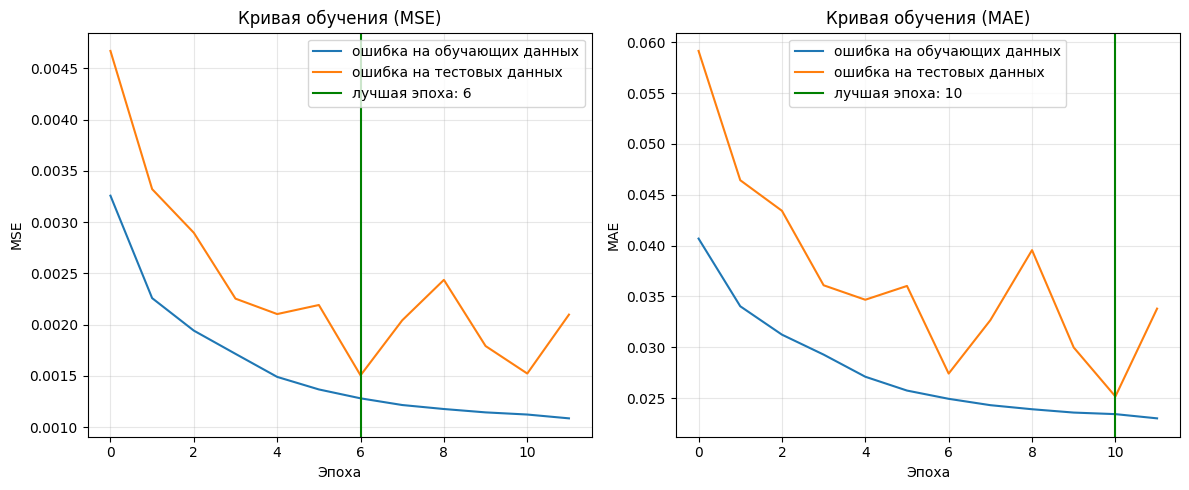

In [ ]:
best_epoch_mse = np.argmin(history_oil.history['val_loss'])
best_epoch_mae = np.argmin(history_oil.history['val_mae'])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_oil.history['loss'], label='ошибка на обучающих данных')
plt.plot(history_oil.history['val_loss'], label='ошибка на тестовых данных')
plt.axvline(x=best_epoch_mse, color='green', label=f'лучшая эпоха: {best_epoch_mse}')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Кривая обучения (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_oil.history['mae'], label='ошибка на обучающих данных')
plt.plot(history_oil.history['val_mae'], label='ошибка на тестовых данных')
plt.axvline(x=best_epoch_mae, color='green', label=f'лучшая эпоха: {best_epoch_mae}')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Кривая обучения (MAE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
y_oil_pred = model.predict(x_oil_test)

2370/2370 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


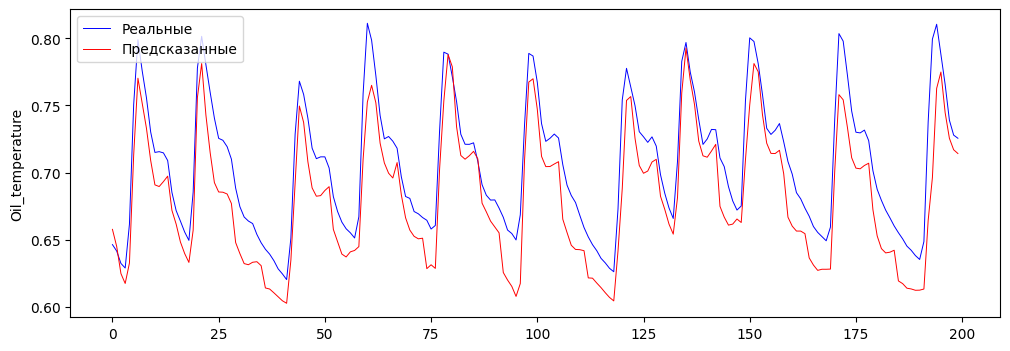

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_oil_test[:200], label='Реальные', linewidth=0.7, color='blue')
plt.plot(y_oil_pred[:200], label='Предсказанные', linewidth=0.7, color='red')
plt.ylabel('Oil_temperature')
plt.legend()
plt.show()

In [ ]:
# средняя квадратичная ошибка (на сколько в среднем модель ошибается, но штрафует за большие ошибки)
mse = mean_squared_error(y_oil_test, y_oil_pred)

# средняя абсолютная ошибка (на сколько в среднем модель ошибается)
mae = mean_absolute_error(y_oil_test, y_oil_pred)

# если мсе и мае примерно одинаковые, значит выбросов мало, если же мсе намного больше - есть сильные выбросы

# коэффициент детерминации (на сколько наша модель лучше другой (самой простой, которая предсказывает среднее значение))
r2 = r2_score(y_oil_test, y_oil_pred)

oil_idx = df_min.columns.get_loc('Oil_temperature')
range_oil = scaler.data_max_[oil_idx] - scaler.data_min_[oil_idx]

mse_real = mse * (range_oil ** 2)
mae_real = mae * range_oil

print(f"Минимум:                {df_min['Oil_temperature'].min():.4f}")
print(f"Максимум:               {df_min['Oil_temperature'].max():.4f}")
print(f"Среднее:                {df_min['Oil_temperature'].mean():.4f}")
print(f"Стандартное отклонение: {df_min['Oil_temperature'].std():.4f}")

print(f"\nМетрики    нормированный масштаб    реальный масштаб")
print(f"MSE              {mse:.4f}                {mse_real:.4f}")
print(f"MAE              {mae:.4f}                {mae_real:.4f}")
print(f"R^2              {r2:.4f}                {r2:.4f}")

Минимум:                15.4000
Максимум:               88.7958
Среднее:                62.6430
Стандартное отклонение: 6.5005

Метрики    нормированный масштаб    реальный масштаб
MSE              0.0015                8.1119
MAE              0.0274                2.0115
R^2              0.6042                0.6042


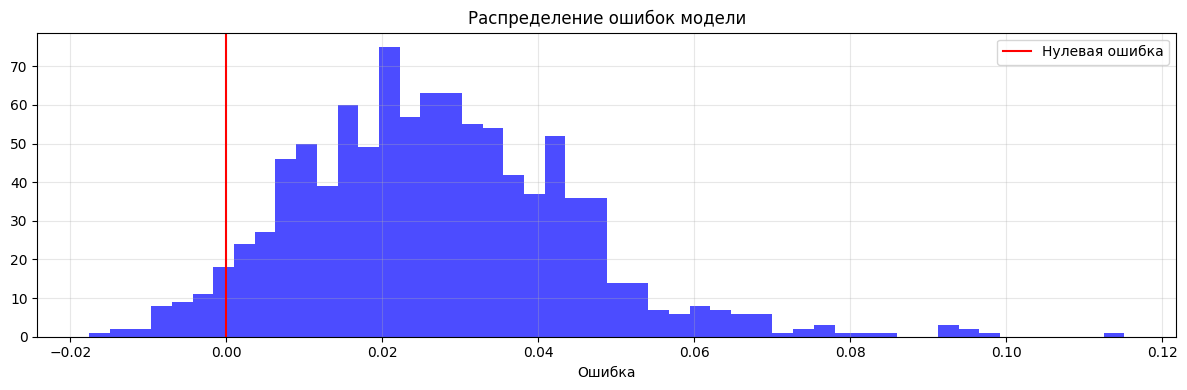

In [ ]:
y_pred_ = y_oil_pred.flatten()
errors = y_oil_test[:1000] - y_pred_[:1000]
std_error = np.std(errors)

plt.figure(figsize=(12, 4))
plt.hist(errors, bins=50, alpha=0.7, color='blue')
plt.axvline(x=0, color='red', linewidth=1.5, label='Нулевая ошибка')
plt.xlabel('Ошибка')
plt.title('Распределение ошибок модели', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

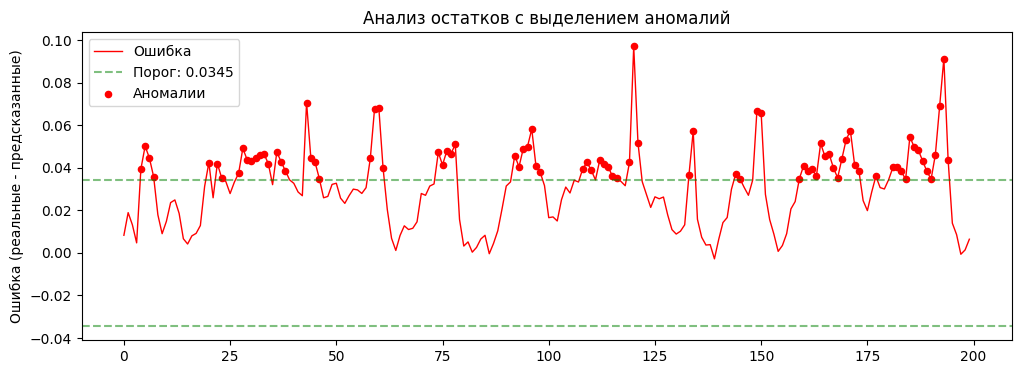

Найдено 85 аномальных точек
Процент аномалий: 42.50%


In [ ]:
y_pred_ = y_oil_pred.flatten()
errors = y_oil_test[:200] - y_pred_[:200]
std_error = np.std(errors)
threshold = 2 * std_error  # или 3 сигмы
anomaly_points = np.where(np.abs(errors) > threshold)[0]

plt.figure(figsize=(12, 4))
plt.plot(errors, linewidth=1, color='red', label='Ошибка')
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Порог: {threshold:.4f}', alpha=0.5)
plt.axhline(y=-threshold, color='green', linestyle='--', alpha=0.5)
plt.scatter(anomaly_points, errors[anomaly_points], color='red', s=20, label='Аномалии')
plt.ylabel('Ошибка (реальные - предсказанные)')
plt.legend()
plt.title('Анализ остатков с выделением аномалий')
plt.show()

# Вывод информации об аномалиях
print(f"Найдено {len(anomaly_points)} аномальных точек")
print(f"Процент аномалий: {len(anomaly_points)/len(errors)*100:.2f}%")